# c-GC* Motor-Neuron Analysis

This notebook runs the supplied `GcStar` c-GC implementation on the Zenodo motor-neuron dataframe in `data/motoneurons`.
It analyzes every unique `Fish`/`Trace`/`fluo_type` trace by default, saves weighted retained adjacency matrices to a `.pkl`, and reloads the cache for plotting so visualization does not require rerunning the estimator.

The saved `adjacency` and `weighted_adjacency` matrices are weighted retained scores in `[source, target]` orientation. Zero means no retained edge; the boolean support is saved separately as `mask`.


In [1]:
from pathlib import Path
from datetime import datetime
import importlib.util
import os
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError as exc:
    raise ImportError(
        "The Zenodo dataframe files are pandas pickles. Install pandas in this "
        "notebook kernel before running this analysis."
    ) from exc

CAUSALISED_GC_RELATIVE_PATH = Path("src/core/causalised-GC.py")
PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (path / CAUSALISED_GC_RELATIVE_PATH).exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find {CAUSALISED_GC_RELATIVE_PATH}; run from the repository or notebooks directory."
    )

SRC = PROJECT_ROOT / "src"
CORE = SRC / "core"
for path in (SRC, CORE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

CAUSALISED_GC_PATH = PROJECT_ROOT / CAUSALISED_GC_RELATIVE_PATH
spec = importlib.util.spec_from_file_location("causalised_gc", CAUSALISED_GC_PATH)
causalised_gc = importlib.util.module_from_spec(spec)
assert spec.loader is not None
sys.modules[spec.name] = causalised_gc
spec.loader.exec_module(causalised_gc)
GcStar = causalised_gc.GcStar

print(f"Project root: {PROJECT_ROOT}")
print(f"Loaded GcStar from {CAUSALISED_GC_PATH}")

from calcium_transient_rising_flank import graph_summary, plot_directed_graph, plot_matrix


Project root: /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank
Loaded GcStar from /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/src/core/causalised-GC.py


/Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configure Data, Estimator, and Outputs


In [2]:
METHOD = "cgc-star"
METHOD_SLUG = "cgc_star"
NOTEBOOK_NAME = "c-GC-star_Motoneurons.ipynb"

DATA_FILE = PROJECT_ROOT / "data" / "motoneurons" / "df_motorneurons_F3T1_F3T2_F5T2.pkl"
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Expected motoneuron dataframe at {DATA_FILE}")

# Manuscript-level defaults. Override from the shell before launching Jupyter if needed.
ALPHA = float(os.environ.get("RF_ALPHA", "0.01"))
BETA = float(os.environ.get("RF_CONDITIONAL_ALPHA", "0.001"))
N_PASTS = int(os.environ.get("RF_N_PASTS", "5"))
N_LAGS = int(os.environ.get("RF_N_LAGS", "2"))
N_PERM = int(os.environ.get("RF_N_PERMUTATIONS", "1000"))
SIMULATION = os.environ.get("RF_SIMULATION", "1").lower() not in {"0", "false", "no"}
PARALLEL = os.environ.get("RF_PARALLEL", "0").lower() in {"1", "true", "yes"}
VERBOSE = int(os.environ.get("RF_GC_VERBOSE", "0"))

# Empty means use every unique Fish/Trace/fluo_type trace in the dataframe.
FLUO_TYPES = tuple(
    item.strip()
    for item in os.environ.get("RF_FLUO_TYPES", "").split(",")
    if item.strip()
)
MAX_RECORDINGS = int(os.environ.get("RF_MAX_RECORDINGS", "0"))

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = PROJECT_ROOT.parent / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ADJACENCY_OUTPUT_FILE = OUTPUT_DIR / f"{METHOD_SLUG}_motoneurons_weighted_adjacency_matrices.pkl"
SUMMARY_OUTPUT_FILE = OUTPUT_DIR / f"{METHOD_SLUG}_motoneurons_summary_rows.pkl"
FIGURE_OUTPUT_FILE = FIGURE_DIR / f"{METHOD_SLUG}_motoneurons_weighted_adjacency.png"

print(f"Using motoneuron data file: {DATA_FILE}")
print(f"Method={METHOD}; alpha={ALPHA}; beta={BETA}; n_perm={N_PERM}; n_pasts={N_PASTS}; n_lags={N_LAGS}")


Using motoneuron data file: /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/data/motoneurons/df_motorneurons_F3T1_F3T2_F5T2.pkl
Method=cgc-star; alpha=0.01; beta=0.001; n_perm=1000; n_pasts=5; n_lags=2


## Load Motor-Neuron Data


In [3]:
def _clean_traces(raw, expected_cells=None):
    values = np.asarray(raw, dtype=float)
    if values.ndim != 2:
        raise ValueError(f"Expected 2-D traces, got shape {values.shape}")
    if expected_cells is not None and values.shape[0] != expected_cells and values.shape[1] == expected_cells:
        values = values.T
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    if values.shape[0] > values.shape[1]:
        raise ValueError(
            f"Trace matrix looks transposed or too short: {values.shape}. Expected [n_cells, n_timepoints]."
        )
    return values


def load_motoneuron_records(path):
    df = pd.read_pickle(path)
    if not hasattr(df, "iterrows"):
        raise TypeError(f"Expected a pandas DataFrame, got {type(df)!r}")

    trace_column = "Trial" if "Trial" in df.columns else "Trace" if "Trace" in df.columns else None
    required = {"Fish", "fluo", "fluo_type", "mid"}
    missing = required.difference(df.columns)
    if trace_column is None:
        missing.add("Trial/Trace")
    if missing:
        raise KeyError(f"Motoneuron dataframe is missing required columns: {sorted(missing)}")

    records = []
    seen = set()
    for _, row in df.iterrows():
        fluo_type = str(row["fluo_type"])
        if FLUO_TYPES and fluo_type not in FLUO_TYPES:
            continue
        key = (int(row["Fish"]), int(row[trace_column]), fluo_type)
        if key in seen:
            continue
        seen.add(key)
        expected_cells = int(row["n_cells"]) if "n_cells" in df.columns else None
        traces = _clean_traces(row["fluo"], expected_cells=expected_cells)
        records.append(
            {
                "key": key,
                "recording": f"F{key[0]}T{key[1]}",
                "fish": key[0],
                "trial": key[1],
                "fluo_type": fluo_type,
                "traces": traces,
                "mid": int(row["mid"]),
                "n_cells": int(traces.shape[0]),
                "n_timepoints": int(traces.shape[1]),
            }
        )
        if MAX_RECORDINGS and len(records) >= MAX_RECORDINGS:
            break
    if not records:
        raise ValueError("No motoneuron records matched the requested filters.")
    return records


records = load_motoneuron_records(DATA_FILE)
for record in records:
    print(
        f"Loaded {record['recording']} {record['fluo_type']}: "
        f"{record['n_cells']} cells x {record['n_timepoints']} frames; mid={record['mid']}"
    )


Loaded F3T1 dff: 14 cells x 1000 frames; mid=7
Loaded F3T2 dff: 11 cells x 1000 frames; mid=6
Loaded F5T2 dff: 17 cells x 1000 frames; mid=9
Loaded F3T1 f_smooth: 14 cells x 1000 frames; mid=7
Loaded F3T2 f_smooth: 11 cells x 1000 frames; mid=6
Loaded F5T2 f_smooth: 17 cells x 1000 frames; mid=9


## Fit and Save Weighted Adjacency Matrices


In [4]:
def fit_gcstar(traces):
    estimator = GcStar(
        n_perm=N_PERM,
        n_pasts=N_PASTS,
        n_lags=N_LAGS,
        temporal=True,
        method=METHOD,
        parallel=PARALLEL,
    )
    estimator.fit(traces, verbose=VERBOSE)
    matrix = estimator.get_connectivity_matrix(
        alpha=ALPHA,
        beta=BETA,
        simulation=False,
    )
    matrix = np.nan_to_num(np.asarray(matrix, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(matrix, 0.0)
    return estimator, matrix


def _estimator_payload(estimator, matrix):
    return {
        "adjacency": matrix,
        "weighted_adjacency": matrix,
        "mask": matrix > 0.0,
        "corr": np.asarray(estimator.corr_, dtype=float),
        "p_values_corr": np.asarray(estimator.pVal_corr_, dtype=float),
        "inv_corr": np.asarray(estimator.inv_corr_, dtype=float),
        "p_values_inv_corr": np.asarray(estimator.pVal_inv_corr_, dtype=float),
        "method_internal": estimator.method,
    }

results = {}
summary_rows = []
for index, record in enumerate(records, start=1):
    print(f"[{index}/{len(records)}] Fitting {METHOD} on {record['recording']} {record['fluo_type']}...", flush=True)
    estimator, matrix = fit_gcstar(record["traces"])
    summary = graph_summary(matrix, record["mid"], binary=False)
    payload = _estimator_payload(estimator, matrix)
    payload.update(
        {
            "recording": record["recording"],
            "fish": record["fish"],
            "trial": record["trial"],
            "fluo_type": record["fluo_type"],
            "mid": record["mid"],
            "n_cells": record["n_cells"],
            "n_timepoints": record["n_timepoints"],
            "summary": summary,
        }
    )
    results[record["key"]] = payload
    summary_rows.append(
        {
            "dataset": "motoneurons",
            "recording": record["recording"],
            "fish": record["fish"],
            "trial": record["trial"],
            "fluo_type": record["fluo_type"],
            "method": METHOD,
            "method_internal": estimator.method,
            **summary,
        }
    )
    print(
        f"    retained_edges={summary['retained_edges']}; "
        f"edge_density={summary['edge_density']:.4f}; W_IC={summary['w_ic']}"
    )

adjacency_cache = {
    "metadata": {
        "dataset": "motoneurons",
        "source_file": str(DATA_FILE),
        "notebook": NOTEBOOK_NAME,
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "method_requested": METHOD,
        "alpha": ALPHA,
        "beta": BETA,
        "n_pasts": N_PASTS,
        "n_lags": N_LAGS,
        "n_perm": N_PERM,
        "simulation": SIMULATION,
        "adjacency_definition": "weighted retained c-GC score matrix; zero means absent edge",
        "orientation": "[source, target]",
    },
    "records": results,
    "summary_rows": summary_rows,
}

with ADJACENCY_OUTPUT_FILE.open("wb") as handle:
    pickle.dump(adjacency_cache, handle)
with SUMMARY_OUTPUT_FILE.open("wb") as handle:
    pickle.dump(summary_rows, handle)

print(f"Saved weighted adjacency cache to {ADJACENCY_OUTPUT_FILE}")
print(f"Saved summary rows to {SUMMARY_OUTPUT_FILE}")


[1/6] Fitting cgc-star on F3T1 dff...
    retained_edges=55; edge_density=0.3022; W_IC=1.0
[2/6] Fitting cgc-star on F3T2 dff...
    retained_edges=39; edge_density=0.3545; W_IC=0.9951698085937778
[3/6] Fitting cgc-star on F5T2 dff...
    retained_edges=115; edge_density=0.4228; W_IC=0.9105744340885161
[4/6] Fitting cgc-star on F3T1 f_smooth...
    retained_edges=43; edge_density=0.2363; W_IC=1.0
[5/6] Fitting cgc-star on F3T2 f_smooth...
    retained_edges=27; edge_density=0.2455; W_IC=1.0
[6/6] Fitting cgc-star on F5T2 f_smooth...
    retained_edges=86; edge_density=0.3162; W_IC=1.0
Saved weighted adjacency cache to /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/cgc_star_motoneurons_weighted_adjacency_matrices.pkl
Saved summary rows to /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/cgc_star_motoneurons_summary_rows.pkl


## Reload Saved Adjacency Cache


In [5]:
def load_adjacency_cache(path=ADJACENCY_OUTPUT_FILE):
    with Path(path).open("rb") as handle:
        return pickle.load(handle)


adjacency_cache = load_adjacency_cache()
print(f"Loaded cache from {ADJACENCY_OUTPUT_FILE}")
print(adjacency_cache["metadata"])
print(f"Available records: {list(adjacency_cache['records'].keys())}")


Loaded cache from /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/cgc_star_motoneurons_weighted_adjacency_matrices.pkl
{'dataset': 'motoneurons', 'source_file': '/Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/data/motoneurons/df_motorneurons_F3T1_F3T2_F5T2.pkl', 'notebook': 'c-GC-star_Motoneurons.ipynb', 'created_at': '2026-05-28T21:05:48', 'method_requested': 'cgc-star', 'alpha': 0.01, 'beta': 0.001, 'n_pasts': 5, 'n_lags': 2, 'n_perm': 1000, 'simulation': True, 'adjacency_definition': 'weighted retained c-GC score matrix; zero means absent edge', 'orientation': '[source, target]'}
Available records: [(3, 1, 'dff'), (3, 2, 'dff'), (5, 2, 'dff'), (3, 1, 'f_smooth'), (3, 2, 'f_smooth'), (5, 2, 'f_smooth')]


## Plot Saved Results


Saved figure to /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/cgc_star_motoneurons_weighted_adjacency.png


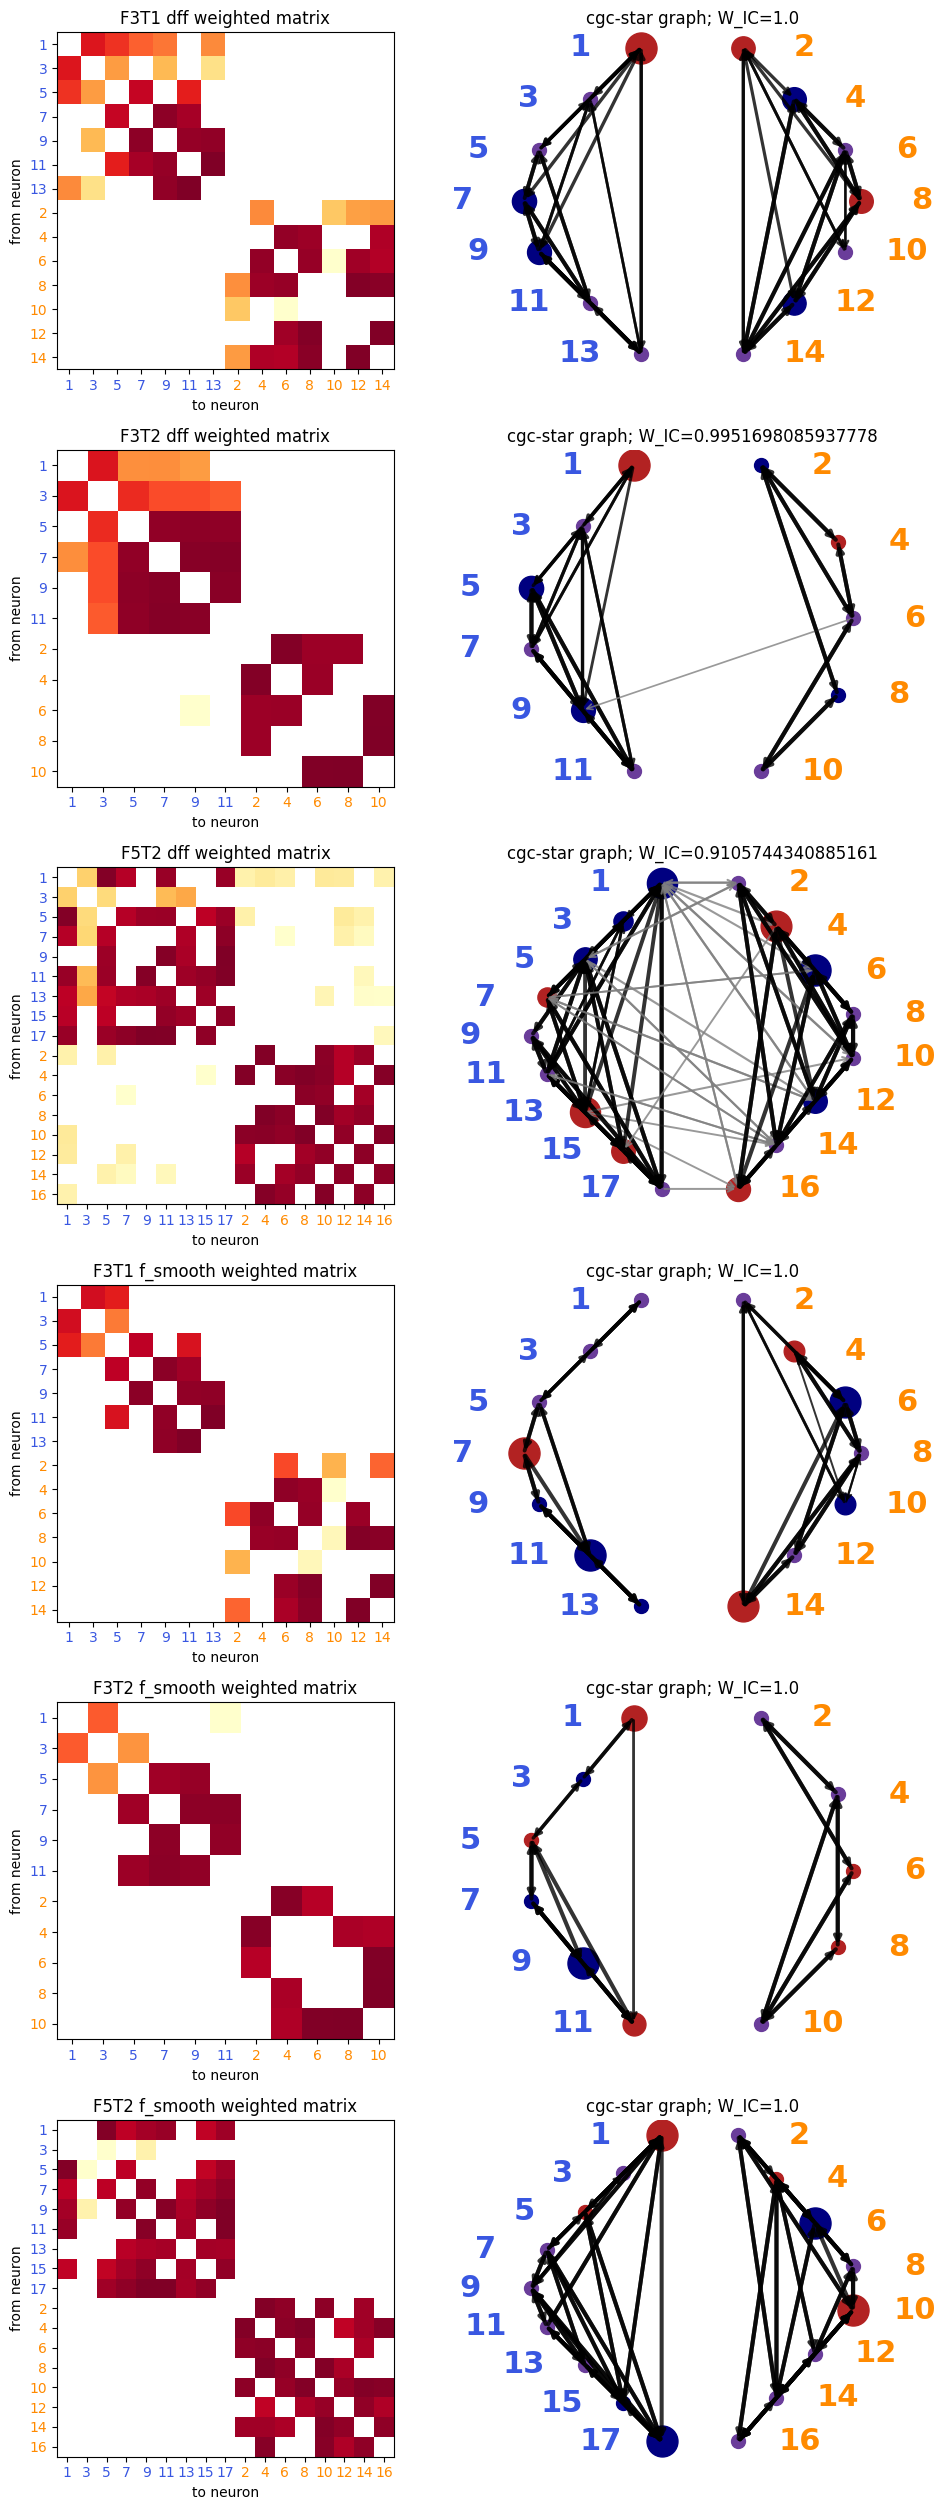

In [6]:
def plot_motoneuron_cache(cache, max_plots=None):
    items = list(cache["records"].items())
    if max_plots is not None:
        items = items[:max_plots]
    if not items:
        raise ValueError("No records available to plot.")
    fig, axes = plt.subplots(len(items), 2, figsize=(10, 4.2 * len(items)))
    axes = np.atleast_2d(axes)
    for row_index, (key, payload) in enumerate(items):
        matrix = np.asarray(payload["weighted_adjacency"], dtype=float)
        mid = int(payload["mid"])
        summary = payload.get("summary", graph_summary(matrix, mid, binary=False))
        plot_matrix(matrix, mid, ax=axes[row_index, 0])
        axes[row_index, 0].set_title(
            f"{payload['recording']} {payload['fluo_type']} weighted matrix"
        )
        plot_directed_graph(matrix, mid, ax=axes[row_index, 1])
        axes[row_index, 1].set_title(
            f"{METHOD} graph; W_IC={summary.get('w_ic')}"
        )
    fig.tight_layout()
    return fig


plot_cache = adjacency_cache if "adjacency_cache" in globals() else load_adjacency_cache()
fig = plot_motoneuron_cache(plot_cache, max_plots=None)
fig.savefig(FIGURE_OUTPUT_FILE, dpi=300, bbox_inches="tight")
print(f"Saved figure to {FIGURE_OUTPUT_FILE}")
plt.show()
